In [29]:
#MULTI LAYER PERCEPTRON FOR XOR FUNCTION
import math

x=[[0,0],[0,1],[1,0],[1,1]]
t=[0,1,1,0]

w13=0.2
w14=0.4
w23=0.2
w24=0.3
w35=0.2
w45=0.3

b3=0.4
b4=0.1
b5=-0.3

lr=0.8

def sigmoid(x):
    return 1/(1+math.exp(-x))

for i in range(4):

    x1=x[i][0]
    x2=x[i][1]

    net3=x1*w13+x2*w23+b3
    net4=x1*w14+x2*w24+b4

    o3=sigmoid(net3)
    o4=sigmoid(net4)

    net5=o3*w35+o4*w45+b5
    o5=sigmoid(net5)

    # Error
    error=t[i]-o5

    # Backpropagation
    delta5=error*o5*(1-o5)

    delta3=o3*(1-o3)*delta5*w35
    delta4=o4*(1-o4)*delta5*w45

    # Weight updates
    w35=w35+lr*delta5*o3
    w45=w45+lr*delta5*o4
    b5=b5+lr*delta5

    w13=w13+lr*delta3*x1
    w23=w23+lr*delta3*x2
    b3=b3+lr*delta3

    w14=w14+lr*delta4*x1
    w24=w24+lr*delta4*x2
    b4=b4+lr*delta4

    print("Input:",x[i])
    print("Hidden 3:",round(o3,4))
    print("Hidden 4:",round(o4,4))
    print("Output:",round(o5,4))
    print("Target:",t[i])
    print("Error:",round(error,4))
    print()

print("Final Weights")
print("w13 =",w13)
print("w14 =",w14)
print("w23 =",w23)
print("w24 =",w24)
print("w35 =",w35)
print("w45 =",w45)
print("b3  =",b3)
print("b4  =",b4)
print("b5  =",b5)

Input: [0, 0]
Hidden 3: 0.5987
Hidden 4: 0.525
Output: 0.4943
Target: 0
Error: -0.4943

Input: [0, 1]
Hidden 3: 0.6446
Hidden 4: 0.5969
Output: 0.4601
Target: 1
Error: 0.5399

Input: [1, 0]
Hidden 3: 0.6454
Hidden 4: 0.6222
Output: 0.5095
Target: 1
Error: 0.4905

Input: [1, 1]
Hidden 3: 0.6924
Hidden 4: 0.6942
Output: 0.5633
Target: 0
Error: -0.5633

Final Weights
w13 = 0.19826083254961357
w14 = 0.39841250100044795
w23 = 0.19701002696745482
w24 = 0.29762284051082644
w35 = 0.1964940495602587
w45 = 0.29620454463509727
b3  = 0.39697245243267576
b4  = 0.09742243137084067
b5  = -0.30436077906029846


In [30]:
#MULTI LAYER PERCEPTRON
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

iris=load_iris()
X=iris.data
y=iris.target

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

model=Sequential([
    Input(shape=(4,)),
    Dense(16,activation="relu"),
    Dense(8,activation="relu"),
    Dense(3,activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

loss,accuracy=model.evaluate(X_test,y_test)
print("Test Accuracy:",accuracy)

prediction=model.predict(X_test[:5])
print("Predicted:",np.argmax(prediction,axis=1))
print("Actual:   ",y_test[:5])

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4375 - loss: 0.8542 - val_accuracy: 0.4583 - val_loss: 0.8290
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4896 - loss: 0.8333 - val_accuracy: 0.5417 - val_loss: 0.8091
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4896 - loss: 0.8147 - val_accuracy: 0.5417 - val_loss: 0.7923
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5208 - loss: 0.7986 - val_accuracy: 0.6250 - val_loss: 0.7763
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6354 - loss: 0.7840 - val_accuracy: 0.7083 - val_loss: 0.7621
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7396 - loss: 0.7699 - val_accuracy: 0.8750 - val_loss: 0.7487
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7917 - loss: 0.7572 - val_accuracy: 0.8750 - val_loss: 0.7369
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8333 - loss: 0.7450 - val_accuracy: 0.8750 - val_loss: 0.7259
E

In [31]:
#LEARNING RATE TUNING
import tensorflow as tf
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

iris=load_iris()
X=iris.data
y=iris.target

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

def create_model(learning_rate):
    model=Sequential([
        Input(shape=(4,)),
        Dense(16,activation="relu"),
        Dense(8,activation="relu"),
        Dense(3,activation="softmax")
    ])

    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

learning_rates=[0.1,0.01,0.001,0.0001]

for lr in learning_rates:
    print("\nLearning Rate:",lr)

    model=create_model(lr)

    model.fit(X_train,y_train,epochs=50,batch_size=16,verbose=0)

    loss,accuracy=model.evaluate(X_test,y_test,verbose=0)

    print("Accuracy:",accuracy)


Learning Rate: 0.1
Accuracy: 0.9666666388511658

Learning Rate: 0.01
Accuracy: 0.9666666388511658

Learning Rate: 0.001
Accuracy: 0.8999999761581421

Learning Rate: 0.0001
Accuracy: 0.699999988079071


In [32]:
#NO HIDDEN LAYER TUNING 
import tensorflow as tf
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

iris=load_iris()
X=iris.data
y=iris.target

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

model1=Sequential([
    Input(shape=(4,)),
    Dense(16,activation="relu"),
    Dense(3,activation="softmax")
])

model2=Sequential([
    Input(shape=(4,)),
    Dense(16,activation="relu"),
    Dense(8,activation="relu"),
    Dense(3,activation="softmax")
])

model3=Sequential([
    Input(shape=(4,)),
    Dense(32,activation="relu"),
    Dense(16,activation="relu"),
    Dense(8,activation="relu"),
    Dense(3,activation="softmax")
])

models=[model1,model2,model3]

for i,model in enumerate(models):
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(X_train,y_train,epochs=50,batch_size=16,verbose=0)

    loss,accuracy=model.evaluate(X_test,y_test,verbose=0)

    print("Model",i+1,"Accuracy:",accuracy)

Model 1 Accuracy: 0.8666666746139526
Model 2 Accuracy: 0.7666666507720947
Model 3 Accuracy: 0.9333333373069763


In [33]:
#NO OF NUERONS TUNING
import tensorflow as tf
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

iris=load_iris()
X=iris.data
y=iris.target

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

neurons=[8,16,32,64]

for n in neurons:
    model=Sequential([
        Input(shape=(4,)),
        Dense(n,activation="relu"),
        Dense(n//2,activation="relu"),
        Dense(3,activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(X_train,y_train,epochs=50,batch_size=16,verbose=0)

    loss,accuracy=model.evaluate(X_test,y_test,verbose=0)

    print("Neurons:",n,"Accuracy:",accuracy)

Neurons: 8 Accuracy: 0.6000000238418579
Neurons: 16 Accuracy: 0.8666666746139526
Neurons: 32 Accuracy: 0.9666666388511658
Neurons: 64 Accuracy: 0.9666666388511658


In [34]:
#BATCH SIZE TUNING
import tensorflow as tf
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

iris=load_iris()
X=iris.data
y=iris.target

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

batch_sizes=[8,16,32,64]

for batch in batch_sizes:
    model=Sequential([
        Input(shape=(4,)),
        Dense(16,activation="relu"),
        Dense(8,activation="relu"),
        Dense(3,activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(X_train,y_train,epochs=50,batch_size=batch,verbose=0)

    loss,accuracy=model.evaluate(X_test,y_test,verbose=0)

    print("Batch Size:",batch,"Accuracy:",accuracy)

Batch Size: 8 Accuracy: 0.9333333373069763
Batch Size: 16 Accuracy: 0.8999999761581421
Batch Size: 32 Accuracy: 0.8333333134651184
Batch Size: 64 Accuracy: 0.7666666507720947


In [38]:
#EPOCH TUNING
import tensorflow as tf
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

iris=load_iris()
X=iris.data
y=iris.target

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

epochs_list=[10,25,50,100]

for epochs in epochs_list:
    model=Sequential([
        Input(shape=(4,)),
        Dense(16,activation="relu"),
        Dense(8,activation="relu"),
        Dense(3,activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=16,
        verbose=0
    )

    loss,accuracy=model.evaluate(X_test,y_test,verbose=0)

    print("Epochs:",epochs,"Accuracy:",accuracy)

Epochs: 10 Accuracy: 0.7333333492279053
Epochs: 25 Accuracy: 0.7666666507720947
Epochs: 50 Accuracy: 0.8999999761581421
Epochs: 100 Accuracy: 0.9666666388511658


In [15]:
#pickng good classifier

import math

w1 = float(input("classifier 1 - W1 : "))
w2=float(input("classifier 1 - W2: "))

w3=float(input("classifier 2 - W1: "))
w4=float(input("classifier 2 - W2: "))

d1=2/math.sqrt(w1**2+w2**2)
d2=2/math.sqrt(w3**2+w4**2)

print("d1= ",d1)

print("d2= ",d2)

if d1 > d2:
    print("Good classifier : Classifier 1")
elif d2 > d1:
    print("Good classifier : Classifier 2")
else:
    print("Both classifiers have equal margin")

classifier 1 - W1 :  2
classifier 1 - W2:  2
classifier 2 - W1:  20
classifier 2 - W2:  20


d1=  0.7071067811865475
d2=  0.07071067811865475
Good classifier : Classifier 1


w1 =  0.8
w2 =  0.4
b =  -1.8000000000000003

Optimal hyperplane:
0.8 *x1 + 0.4 *x2 + -1.8000000000000003 = 0


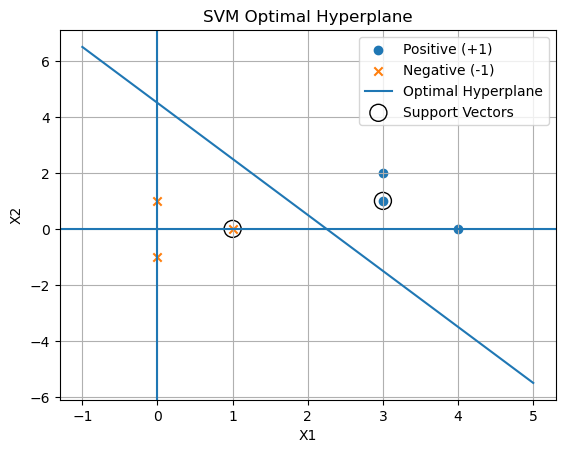

In [16]:
# Optimal hyperplane to classify points

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

X = np.array([
    [3, 1],
    [3, 2],
    [4, 0],
    [1, 0],
    [0, 1],
    [0, -1]
])

y = np.array([1, 1, 1, -1, -1, -1])

model = SVC(kernel='linear', C=1000)

model.fit(X, y)

w = model.coef_[0]

b = model.intercept_[0]

print("w1 = ", w[0])
print("w2 = ", w[1])
print("b = ", b)

print("\nOptimal hyperplane:")

print(w[0], "*x1 +", w[1], "*x2 +", b, "= 0")

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    marker='o',
    label='Positive (+1)'
)

plt.scatter(
    X[y == -1, 0],
    X[y == -1, 1],
    marker='x',
    label='Negative (-1)'
)

x1 = np.linspace(-1, 5, 100)

x2 = -(w[0] * x1 + b) / w[1]

plt.plot(
    x1,
    x2,
    label='Optimal Hyperplane'
)

sv = model.support_vectors_

plt.scatter(
    sv[:, 0],
    sv[:, 1],
    s=150,
    facecolors='none',
    edgecolors='black',
    label='Support Vectors'
)

plt.xlabel("X1")
plt.ylabel("X2")

plt.axhline(0)
plt.axvline(0)

plt.grid(True)

plt.legend()

plt.title("SVM Optimal Hyperplane")

plt.show()

LR: 0.001 Neurons: 16 Dropout: 0.3 Accuracy: 0.8333333134651184
LR: 0.001 Neurons: 32 Dropout: 0.0 Accuracy: 0.9666666388511658
LR: 0.001 Neurons: 32 Dropout: 0.2 Accuracy: 0.9333333373069763
LR: 0.001 Neurons: 32 Dropout: 0.3 Accuracy: 0.9333333373069763
LR: 0.0001 Neurons: 8 Dropout: 0.0 Accuracy: 0.5333333611488342
LR: 0.0001 Neurons: 8 Dropout: 0.2 Accuracy: 0.3333333432674408
LR: 0.0001 Neurons: 8 Dropout: 0.3 Accuracy: 0.3333333432674408
LR: 0.0001 Neurons: 16 Dropout: 0.0 Accuracy: 0.4333333373069763
LR: 0.0001 Neurons: 16 Dropout: 0.2 Accuracy: 0.8333333134651184
LR: 0.0001 Neurons: 16 Dropout: 0.3 Accuracy: 0.4333333373069763
LR: 0.0001 Neurons: 32 Dropout: 0.0 Accuracy: 0.800000011920929
LR: 0.0001 Neurons: 32 Dropout: 0.2 Accuracy: 0.699999988079071
LR: 0.0001 Neurons: 32 Dropout: 0.3 Accuracy: 0.699999988079071

========== BEST RESULT ==========
Learning Rate: 0.01
Neurons: 8
Dropout: 0.3
Best Accuracy: 1.0
